# Final Project: TimeGPT

In [1]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("nixtla").setLevel(logging.WARNING)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from nixtla import NixtlaClient
import os
import time

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 0 Load Data

In [2]:
load_dotenv()

nixtla_client = NixtlaClient(api_key=os.getenv("NIXTLA_API_KEY"))
nixtla_client.validate_api_key()

True

In [3]:
df_raw = pd.read_parquet("../../data/processed/merged_features_weekly.parquet")

commodities = [
    "Beetroot",
    "Bulb Onions (Yellow)",
    "Cabbage",
    "Carrots",
    "Cucumbers",
    "Curly kale",
    "Lettuce",
    "Tomatoes (Round)",
]

exog_cols = [
    # ── Core cost drivers (level) ──────────────────────────────────────────
    "api_energy_and_lubricants",
    "api_fertilisers_and_soil_improvers",
    "api_plant_protection_products",
    "api_fresh_fruit",
    "api_fresh_vegetables",
    "fuel_petrol_price",
    "fuel_diesel_price",
    "sppi_road_freight",

    # ── Structural break indicators (deterministic, known in advance) ──────
    # shock_2021q4_2023q1 = 0 in test; post_shock = 1 in test
    "shock_2021q4_2023q1",
    "post_shock",

    # ── Seasonal encodings (deterministic, always known in advance) ────────
    "week_sin",
    "week_cos",
    "month",
    "quarter",

    # ── Short-term momentum of primary cost drivers ────────────────────────
    # Exog lags are valid in X_df: these are observed independently of target
    "fuel_diesel_price_lag_1",
    "fuel_diesel_price_lag_2",
    "fuel_diesel_price_roll_mean_4",
    "api_energy_and_lubricants_lag_1",
    "api_energy_and_lubricants_lag_2",
    "api_energy_and_lubricants_roll_mean_4",
    "sppi_road_freight_lag_1",
    "sppi_road_freight_roll_mean_4",

    # ── Year-over-year trend of key inputs ────────────────────────────────
    "fuel_diesel_price_yoy_diff_52",
    "api_energy_and_lubricants_yoy_diff_52",
    "api_fertilisers_and_soil_improvers_yoy_diff_52",
]

df = df_raw[df_raw["commodity"].isin(commodities)].copy()
df = df.sort_values(["commodity", "date"]).reset_index(drop=True)

In [4]:
# Dates are already weekly Fridays — cast to ns for consistency with pd.date_range
df["date"] = df["date"].astype("datetime64[ns]")

if "target_was_missing" not in df.columns:
    df["target_was_missing"] = 0

filled_parts = []
for comm in commodities:
    sub = df[df["commodity"] == comm].sort_values("date")
    sub = sub.drop_duplicates(subset="date", keep="first")
    sub = sub.dropna(subset=["date"])

    if len(sub) == 0:
        print(f"Skipping {comm}: no valid dates")
        continue

    full_idx = pd.date_range(start=sub["date"].min(), end=sub["date"].max(), freq="W-FRI")
    sub = sub.set_index("date").reindex(full_idx)
    sub.index.name = "date"

    sub["target_price"] = sub["target_price"].interpolate(method="linear")
    sub["commodity"] = comm
    sub["split"] = sub["split"].ffill().bfill()
    # Rows added by reindex are imputed — flag them
    sub["target_was_missing"] = sub["target_was_missing"].fillna(1).astype(int)

    for col in exog_cols:
        if col in sub.columns:
            sub[col] = sub[col].interpolate(method="linear").ffill().bfill()

    filled_parts.append(sub.reset_index())

df_filled = pd.concat(filled_parts, ignore_index=True)

train_df = df_filled[df_filled["split"] == "train"].copy()
test_df  = df_filled[df_filled["split"] == "test"].copy()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

Skipping Beetroot: no valid dates
Skipping Cucumbers: no valid dates
Skipping Curly kale: no valid dates
Skipping Tomatoes (Round): no valid dates
Train: 1876 rows | Test: 240 rows


In [5]:
avail_exog = [c for c in exog_cols if c in df_filled.columns]

# Training dataframe — include exogenous history
nf_train = train_df[["commodity", "date", "target_price"]].copy()# + avail_exog].copy()
nf_train.columns = ["unique_id", "ds", "y"]# + avail_exog
nf_train["y"] = nf_train["y"].astype(float)

# Test dataframe — keep was_missing flag for evaluation
nf_test = test_df[["commodity", "date", "target_price", "target_was_missing"]].copy()
nf_test.columns = ["unique_id", "ds", "y", "was_missing"]
nf_test["y"] = nf_test["y"].astype(float)

# Future exogenous dataframe (no target) passed to forecast as X_df
# X_df = test_df[["commodity", "date"] + avail_exog].copy()
# X_df.columns = ["unique_id", "ds"] + avail_exog
X_df = test_df[["commodity", "date"]].copy()
X_df.columns = ["unique_id", "ds"]

# Infer frequency directly from training series (confirms W-FRI)
sample_train = nf_train[nf_train["unique_id"] == nf_train["unique_id"].iloc[0]].sort_values("ds")
DATA_FREQ = pd.infer_freq(pd.DatetimeIndex(sample_train["ds"]))

# All commodities share the same test window — h is exact, not padded
max_h = nf_test.groupby("unique_id").size().max()
print(f"Max forecast horizon : {max_h} weeks")
print(f"Inferred frequency   : {DATA_FREQ}")
# print(f"Exogenous features   : {avail_exog}")

Max forecast horizon : 60 weeks
Inferred frequency   : W-FRI


## 1 Forecast

In [6]:
start_time = time.time()

timegpt_forecasts = nixtla_client.forecast(
    df=nf_train,
    X_df=X_df if avail_exog else None,
    h=max_h,
    time_col="ds",
    target_col="y",
    id_col="unique_id",
    freq=DATA_FREQ,
    model="timegpt-1-long-horizon",
)

elapsed = time.time() - start_time
print(f"Forecast completed in {elapsed:.1f}s")
timegpt_forecasts.head()

Forecast completed in 2.3s


,unique_id,ds,TimeGPT
0,Bulb Onions (Yellow),2025-01-03,0.510816
1,Bulb Onions (Yellow),2025-01-10,0.505353
2,Bulb Onions (Yellow),2025-01-17,0.515355
3,Bulb Onions (Yellow),2025-01-24,0.508632
4,Bulb Onions (Yellow),2025-01-31,0.501555


## 2 Evaluation

In [7]:
eval_df = nf_test[["unique_id", "ds", "y", "was_missing"]].merge(
    timegpt_forecasts, on=["unique_id", "ds"], how="inner"
)

# Mirror ARIMA: only evaluate on originally-observed (non-imputed) rows
eval_real = eval_df[eval_df["was_missing"] == 0].copy()

print(f"Total test rows : {len(eval_df)}")
print(f"Non-imputed rows used for evaluation: {len(eval_real)}")

Total test rows : 240
Non-imputed rows used for evaluation: 112


In [8]:
def calc_smape(y_true, y_pred):
    """sMAPE matching ARIMA definition: mean(200*|a-p|/(|a|+|p|)), result in %."""
    denom = np.abs(y_true) + np.abs(y_pred)
    return np.mean(np.where(denom == 0, 0, 200 * np.abs(y_true - y_pred) / denom))


def calc_metrics(y_true, y_pred):
    mse  = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan

    smape = calc_smape(y_true, y_pred)

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "sMAPE (%)": smape}

In [9]:
overall_metrics = calc_metrics(eval_real["y"].values, eval_real["TimeGPT"].values)

metrics_df = pd.DataFrame(
    {"Metric": list(overall_metrics.keys()), "Value": list(overall_metrics.values())}
)
print("\nTimeGPT Overall Metrics (non-imputed observations):\n")
print(metrics_df.to_string(index=False))


TimeGPT Overall Metrics (non-imputed observations):

   Metric    Value
      MSE 0.003439
     RMSE 0.058645
      MAE 0.043451
 MAPE (%) 7.400631
sMAPE (%) 7.422268


In [10]:
per_commodity = []
for comm in commodities:
    sub = eval_real[eval_real["unique_id"] == comm]
    if len(sub) > 0:
        m = calc_metrics(sub["y"].values, sub["TimeGPT"].values)
        m["Commodity"] = comm
        per_commodity.append(m)

per_commodity_df = pd.DataFrame(per_commodity)[
    ["Commodity", "RMSE", "MAE", "MAPE (%)", "sMAPE (%)"]
]
print("\nPer-Commodity Metrics (non-imputed observations):\n")
print(per_commodity_df.to_string(index=False))


Per-Commodity Metrics (non-imputed observations):

           Commodity     RMSE      MAE  MAPE (%)  sMAPE (%)
Bulb Onions (Yellow) 0.073793 0.057002 10.225857  10.856489
             Cabbage 0.043885 0.029360  3.923334   4.051487
             Carrots 0.067109 0.051707 10.244620   9.552355
             Lettuce 0.043381 0.035734  5.208713   5.228740


## 3 Forecast Plots

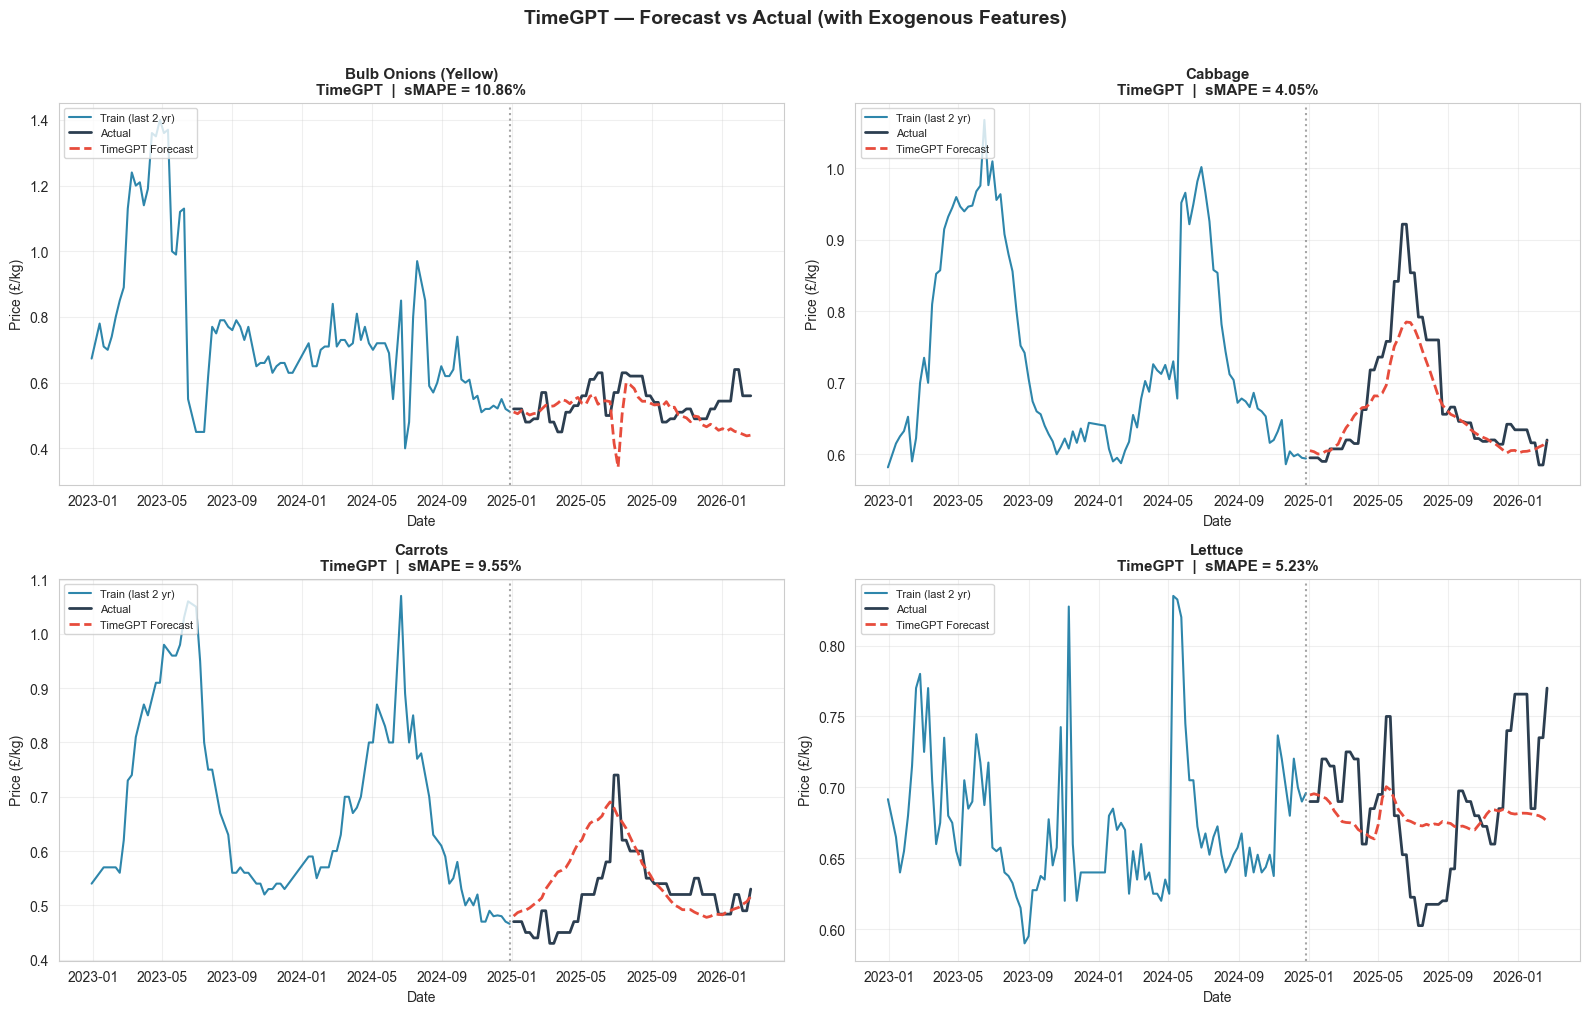

In [11]:
plot_commodities = [c for c in commodities if c in nf_train["unique_id"].values]
ncols = 2
nrows = (len(plot_commodities) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for idx, comm in enumerate(plot_commodities):
    ax = axes[idx]

    train_sub = nf_train[nf_train["unique_id"] == comm].sort_values("ds")
    test_sub  = eval_df[eval_df["unique_id"] == comm].sort_values("ds")

    if train_sub.empty or test_sub.empty:
        ax.set_title(f"{comm} — no data", fontsize=11)
        ax.axis("off")
        continue

    # Show last 2 years of training history (mirrors ARIMA plot)
    cutoff = pd.Timestamp(train_sub["ds"].max()) - pd.DateOffset(years=2)
    train_tail = train_sub[train_sub["ds"] >= cutoff]
    train_end  = pd.Timestamp(train_sub["ds"].max())

    ax.plot(train_tail["ds"], train_tail["y"],
            label="Train (last 2 yr)", color="#2E86AB", linewidth=1.5)
    ax.plot(test_sub["ds"], test_sub["y"],
            label="Actual", color="#2c3e50", linewidth=2)
    ax.plot(test_sub["ds"], test_sub["TimeGPT"],
            label="TimeGPT Forecast", color="#e74c3c", linewidth=2, linestyle="--")

    ax.axvline(x=train_end, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)

    comm_row = per_commodity_df[per_commodity_df["Commodity"] == comm]
    if len(comm_row) > 0:
        smape_val = comm_row["sMAPE (%)"].values[0]
        ax.set_title(f"{comm}\nTimeGPT  |  sMAPE = {smape_val:.2f}%",
                     fontweight="bold", fontsize=11)
    else:
        ax.set_title(comm, fontweight="bold", fontsize=11)

    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (£/kg)")

# Hide any unused subplots
for j in range(len(plot_commodities), len(axes)):
    axes[j].axis("off")

plt.suptitle("TimeGPT — Forecast vs Actual (with Exogenous Features)",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 Summary

In [12]:
print("\n=== TimeGPT Summary ===\n")
print(metrics_df.to_string(index=False))
print(f"\nForecast horizon         : {max_h} weeks")
print(f"Exogenous features used  : {avail_exog}")
print(f"Evaluation observations  : {len(eval_real)} (non-imputed only)")


=== TimeGPT Summary ===

   Metric    Value
      MSE 0.003439
     RMSE 0.058645
      MAE 0.043451
 MAPE (%) 7.400631
sMAPE (%) 7.422268

Forecast horizon         : 60 weeks
Exogenous features used  : ['api_energy_and_lubricants', 'api_fertilisers_and_soil_improvers', 'api_plant_protection_products', 'api_fresh_fruit', 'api_fresh_vegetables', 'fuel_petrol_price', 'fuel_diesel_price', 'sppi_road_freight', 'shock_2021q4_2023q1', 'post_shock', 'week_sin', 'week_cos', 'month', 'quarter', 'fuel_diesel_price_lag_1', 'fuel_diesel_price_lag_2', 'fuel_diesel_price_roll_mean_4', 'api_energy_and_lubricants_lag_1', 'api_energy_and_lubricants_lag_2', 'api_energy_and_lubricants_roll_mean_4', 'sppi_road_freight_lag_1', 'sppi_road_freight_roll_mean_4', 'fuel_diesel_price_yoy_diff_52', 'api_energy_and_lubricants_yoy_diff_52', 'api_fertilisers_and_soil_improvers_yoy_diff_52']
Evaluation observations  : 112 (non-imputed only)
